# 06 - Results: model comparison & paper benchmark

Aggregates every `metrics_*.json` into the comparison table and a Fig-2a-style ROC overlay. The paper reports per-bigclass AUC > 0.99 on 250k images; we compare the *form* at 551 images.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, glob
# auto-locate the folder that actually contains fundus_lib
hits = glob.glob("/content/drive/MyDrive/**/fundus_lib/__init__.py", recursive=True)
assert hits, "fundus_lib not found anywhere under MyDrive — check the upload"
PROJECT_DIR = os.path.dirname(os.path.dirname(hits[0]))
print("PROJECT_DIR ->", PROJECT_DIR)

DATA_ROOT   = os.path.join(PROJECT_DIR, "1000images")
CACHE_DIR   = os.path.join(PROJECT_DIR, "cache_crops")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
MANIFEST    = os.path.join(PROJECT_DIR, "manifest_cached.json")
SPLITS      = os.path.join(PROJECT_DIR, "splits.json")
os.makedirs(RESULTS_DIR, exist_ok=True)

%pip install -q timm transformers torchinfo grad-cam

sys.path.insert(0, PROJECT_DIR)
import fundus_lib as fl
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| imported fundus_lib OK")


MessageError: Error: credential propagation was unsuccessful

## Comparison table

In [ ]:
import json, glob, os, numpy as np, pandas as pd
rows = []
for f in sorted(glob.glob(os.path.join(RESULTS_DIR,"metrics_*.json"))):
    d = json.load(open(f)); s = d["summary"]
    rows.append({"model": d["model"],
                 "weighted_AUC": "%.3f+/-%.3f" % (s["weighted_auc_mean"], s["weighted_auc_std"]),
                 "macro_AUC":    "%.3f+/-%.3f" % (s["macro_auc_mean"], s["macro_auc_std"]),
                 "weighted_F1":  "%.3f+/-%.3f" % (s["weighted_f1_mean"], s["weighted_f1_std"]),
                 "bal_acc":      "%.3f" % s["balanced_accuracy_mean"]})
df = pd.DataFrame(rows); df.to_csv(os.path.join(RESULTS_DIR,"comparison_table.csv"), index=False)
df

,model,weighted_AUC,macro_AUC,weighted_F1,bal_acc
0,cnn,0.932+/-0.017,0.924+/-0.016,0.669+/-0.043,0.616
1,dinov2,0.910+/-0.014,0.899+/-0.016,0.611+/-0.046,0.556
2,resnet50,0.997+/-0.002,0.997+/-0.002,0.936+/-0.032,0.931
3,retfound,0.987+/-0.006,0.983+/-0.005,0.885+/-0.042,0.850
4,vit,0.990+/-0.004,0.987+/-0.005,0.863+/-0.039,0.809


## Weighted AUC vs paper reference

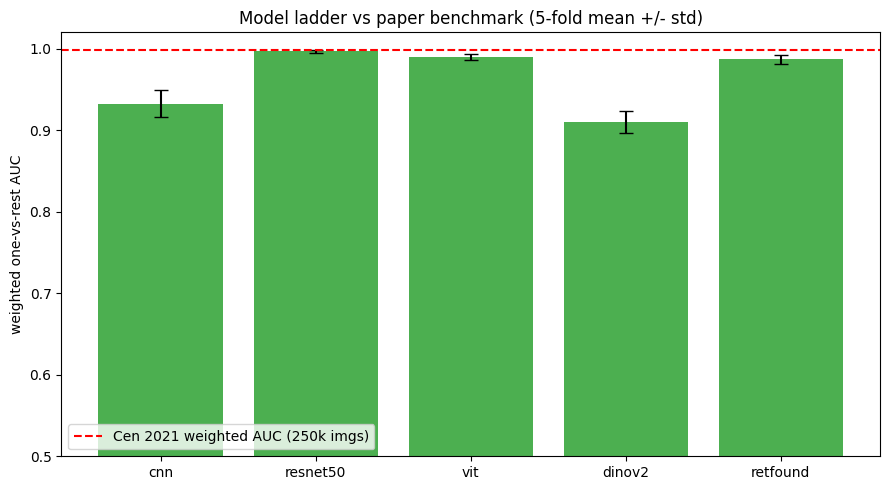

In [ ]:
import matplotlib.pyplot as plt
order = ["cnn","resnet50","vit","dinov2","retfound"]
means, stds, labels = [], [], []
for m in order:
    p = os.path.join(RESULTS_DIR, "metrics_%s.json" % m)
    if not os.path.exists(p): continue
    s = json.load(open(p))["summary"]
    means.append(s["weighted_auc_mean"]); stds.append(s["weighted_auc_std"]); labels.append(m)
plt.figure(figsize=(9,5))
plt.bar(labels, means, yerr=stds, capsize=5, color="#4CAF50")
plt.axhline(0.998, ls="--", color="red", label="Cen 2021 weighted AUC (250k imgs)")
plt.ylim(0.5,1.02); plt.ylabel("weighted one-vs-rest AUC"); plt.legend()
plt.title("Model ladder vs paper benchmark (5-fold mean +/- std)")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR,"auc_comparison.png"), dpi=150); plt.show()

## Fig-2a-style ROC overlay (best model)

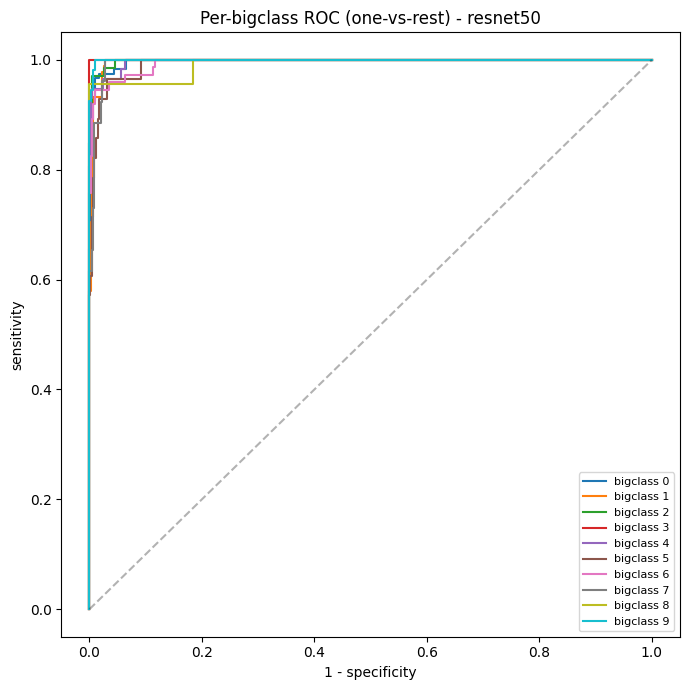

In [ ]:
import numpy as np, matplotlib.pyplot as plt
order = ["cnn","resnet50","vit","dinov2","retfound"]
avail = [m for m in order if os.path.exists(os.path.join(RESULTS_DIR,"metrics_%s.json"%m))]
best = max(avail, key=lambda m: json.load(open(os.path.join(RESULTS_DIR,"metrics_%s.json"%m)))["summary"]["weighted_auc_mean"])
d = np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % best))
yt, yp = d["y_true"], d["y_prob"]
plt.figure(figsize=(7,7))
for k in range(yp.shape[1]):
    pts = fl.metrics.roc_points(yt, yp, k)
    if pts is None: continue
    plt.plot(pts[0], pts[1], label="bigclass %d" % k)
plt.plot([0,1],[0,1],"k--",alpha=0.3)
plt.xlabel("1 - specificity"); plt.ylabel("sensitivity")
plt.title("Per-bigclass ROC (one-vs-rest) - %s" % best)
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR,"roc_overlay.png"), dpi=150); plt.show()

## Per-disease AUC heatmap across models

One row per model, one column per bigclass. Reveals where the foundation-model ladder pays off — which classes only become solvable with retina-pretraining (RETFound), and which the vanilla CNN already nails.


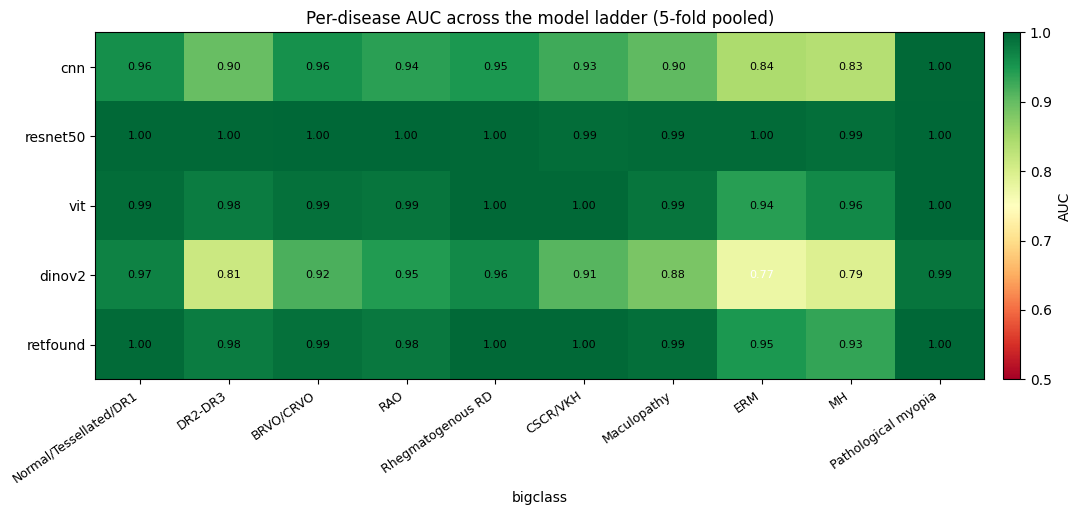

In [ ]:
import os, json, numpy as np, matplotlib.pyplot as plt

order = ["cnn","resnet50","vit","dinov2","retfound"]
avail = [m for m in order if os.path.exists(os.path.join(RESULTS_DIR,"metrics_%s.json"%m))]
short = fl.metrics.bigclass_short

# build (M, K) matrix of per-class AUCs from each model's pooled OOF preds
matrix, labels = [], []
for m in avail:
    d = json.load(open(os.path.join(RESULTS_DIR,"metrics_%s.json"%m)))
    pc = d["per_class_auc_pooled"]
    # keys may be either string class indices or bigclass ints depending on save
    row = []
    for k in range(len(short)):
        # try int key, then str
        v = pc.get(k, pc.get(str(k), pc.get(k, np.nan)))
        if isinstance(v, str): v = float(v)
        row.append(float(v) if v is not None else np.nan)
    matrix.append(row)
    labels.append(m)
M = np.array(matrix)

fig, ax = plt.subplots(figsize=(11, 0.55*len(labels)+2.5))
im = ax.imshow(M, cmap="RdYlGn", vmin=0.5, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(short))); ax.set_xticklabels([short[k] for k in range(len(short))],
                                                     rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("bigclass"); ax.set_title("Per-disease AUC across the model ladder (5-fold pooled)")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if not np.isnan(M[i,j]):
            ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center",
                    fontsize=8, color="black" if M[i,j] > 0.78 else "white")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="AUC")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"per_class_auc_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()


## Per-fold variability across the ladder

Dot plot of each fold's weighted F1 + weighted AUC per model. If the spread for a model is wide, its headline number is partly luck-of-the-split — relevant for small-N studies like ours (~551 images).


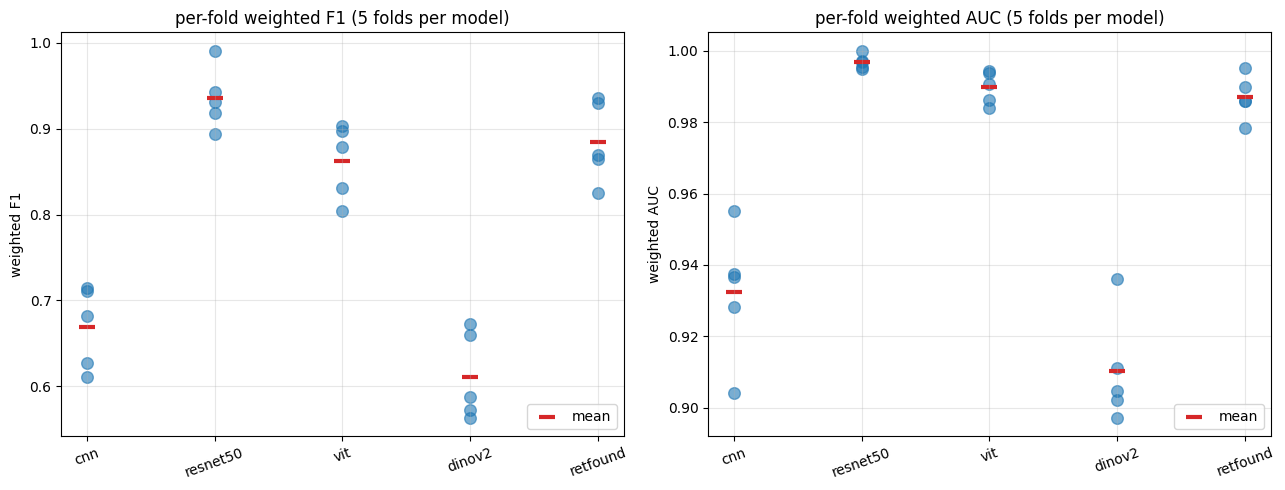

In [ ]:
import os, json, numpy as np, matplotlib.pyplot as plt

order = ["cnn","resnet50","vit","dinov2","retfound"]
avail = [m for m in order if os.path.exists(os.path.join(RESULTS_DIR,"metrics_%s.json"%m))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric_key, ylabel in [
    (axes[0], "weighted_f1", "weighted F1"),
    (axes[1], "weighted_auc", "weighted AUC"),
]:
    for xi, m in enumerate(avail):
        d = json.load(open(os.path.join(RESULTS_DIR,"metrics_%s.json"%m)))
        vals = [fold[metric_key] for fold in d["per_fold"]]
        ax.scatter([xi]*len(vals), vals, s=70, alpha=0.6, color="tab:blue")
        ax.scatter([xi], [np.mean(vals)], s=140, marker="_", color="tab:red", lw=3, label="mean" if xi==0 else None)
    ax.set_xticks(range(len(avail))); ax.set_xticklabels(avail, rotation=20)
    ax.set_ylabel(ylabel); ax.set_title(f"per-fold {ylabel} (5 folds per model)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"per_fold_variability.png"), dpi=150, bbox_inches="tight")
plt.show()


## Side-by-side per-disease ROC across models

Same Fig 2a layout repeated once per model, drawn on a shared (0,1) axis with the chance line. Visualizes the gap between rungs of the ladder.


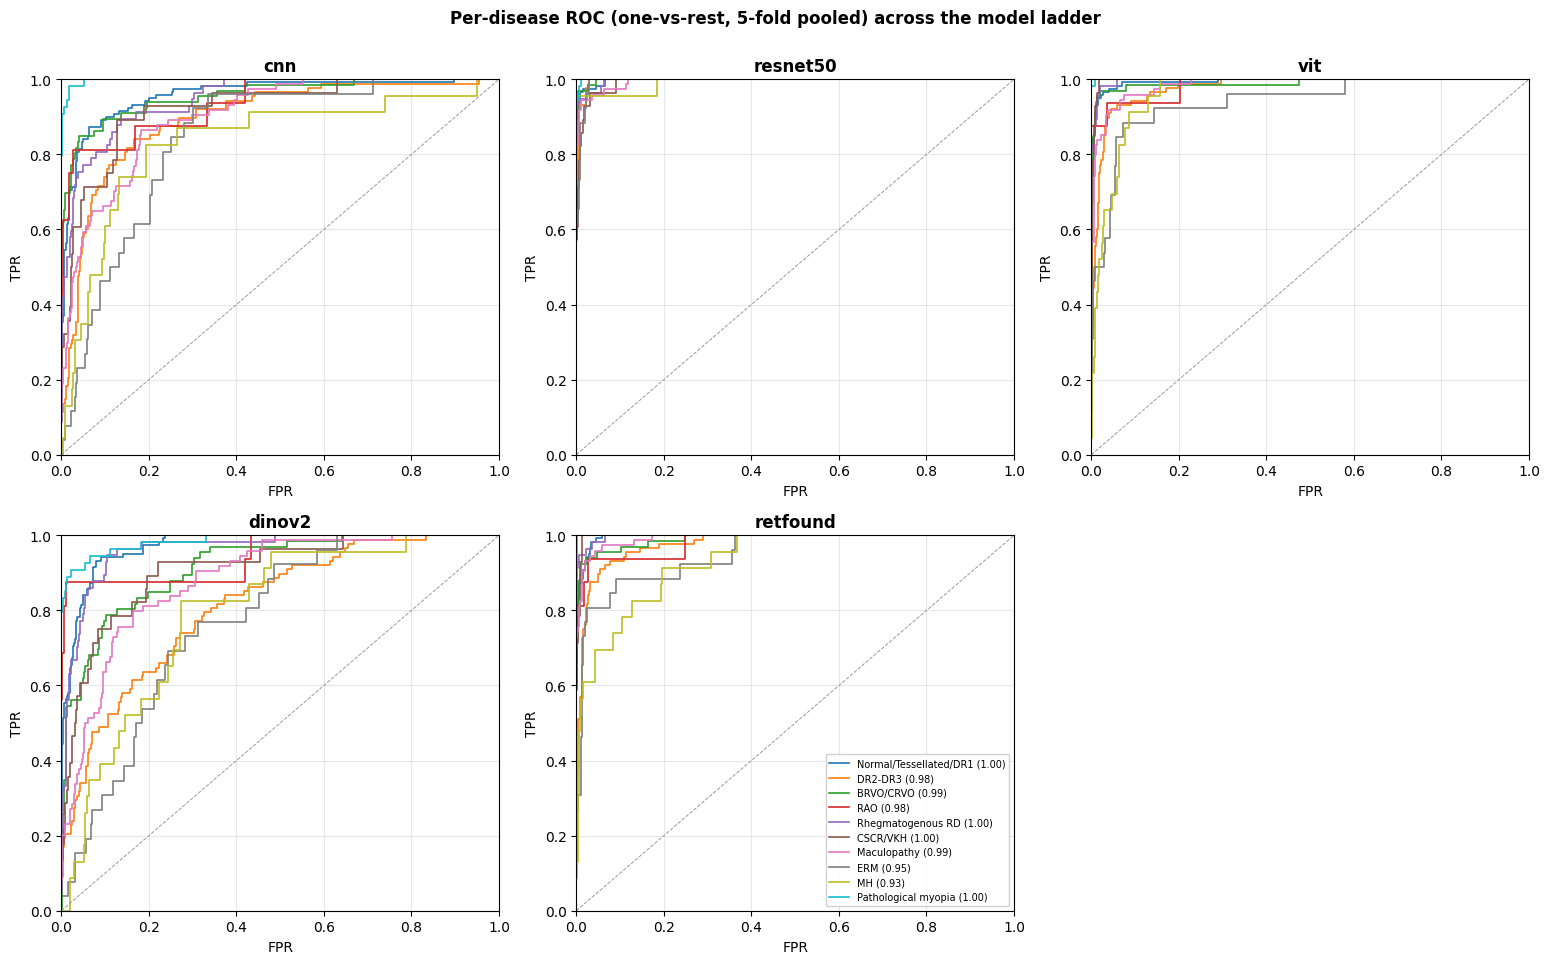

In [ ]:
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

order = ["cnn","resnet50","vit","dinov2","retfound"]
avail = [m for m in order if os.path.exists(os.path.join(RESULTS_DIR,"preds_%s.npz"%m))]
short = fl.metrics.bigclass_short

cols = 3 if len(avail) >= 3 else len(avail)
rows = int(np.ceil(len(avail) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5.2*cols, 4.8*rows), squeeze=False)
cmap = plt.get_cmap("tab10")

for ax, m in zip(axes.flat, avail):
    d = np.load(os.path.join(RESULTS_DIR,"preds_%s.npz"%m))
    yt, yp = d["y_true"], d["y_prob"]
    for k in range(yp.shape[1]):
        b = (yt==k).astype(int)
        if b.sum()==0 or b.sum()==len(b): continue
        fpr, tpr, _ = roc_curve(b, yp[:,k])
        auc = roc_auc_score(b, yp[:,k])
        ax.plot(fpr, tpr, color=cmap(k%10), lw=1.2, label=f"{short[k]} ({auc:.2f})")
    ax.plot([0,1],[0,1],"0.6",ls="--",lw=0.7)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(m, fontweight="bold")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.grid(True, alpha=0.3)
# legend on last used axis only (avoids 5x repeat)
axes.flat[len(avail)-1].legend(fontsize=7, loc="lower right", framealpha=0.9)
# blank any unused panels
for ax in axes.flat[len(avail):]:
    ax.axis("off")
plt.suptitle("Per-disease ROC (one-vs-rest, 5-fold pooled) across the model ladder",
             fontsize=12, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"roc_grid_models.png"), dpi=150, bbox_inches="tight")
plt.show()


## Explainability across the model ladder

One fundus image, four attribution methods (Grad-CAM++, SmoothGrad, vanilla saliency, guided backprop) down the rows, every trained model across the columns — so you can see how each rung attends to the **same eye**, and where retina-pretraining changes what the network looks at. Each column reports that model's own prediction; maps explain the predicted class. Set `IMG_IDX`/`PREFERRED_BIGCLASS` to inspect a different eye. Saved to `results/explainability_grid.png`.

_Note: guided backprop is ReLU-gated, so it only differs from vanilla saliency on the convnets (cnn, resnet50); the transformer rungs use GELU and fall back to a plain gradient there._

explaining image idx 497 | true bigclass: Pathological myopia
  cnn       pred=Pathological myopia    p=0.97
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 232MB/s]


  resnet50  pred=Pathological myopia    p=1.00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  vit       pred=Pathological myopia    p=1.00


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  dinov2    pred=Pathological myopia    p=1.00
retfound weights loaded. missing=2 unexpected=0
  retfound  pred=Pathological myopia    p=1.00


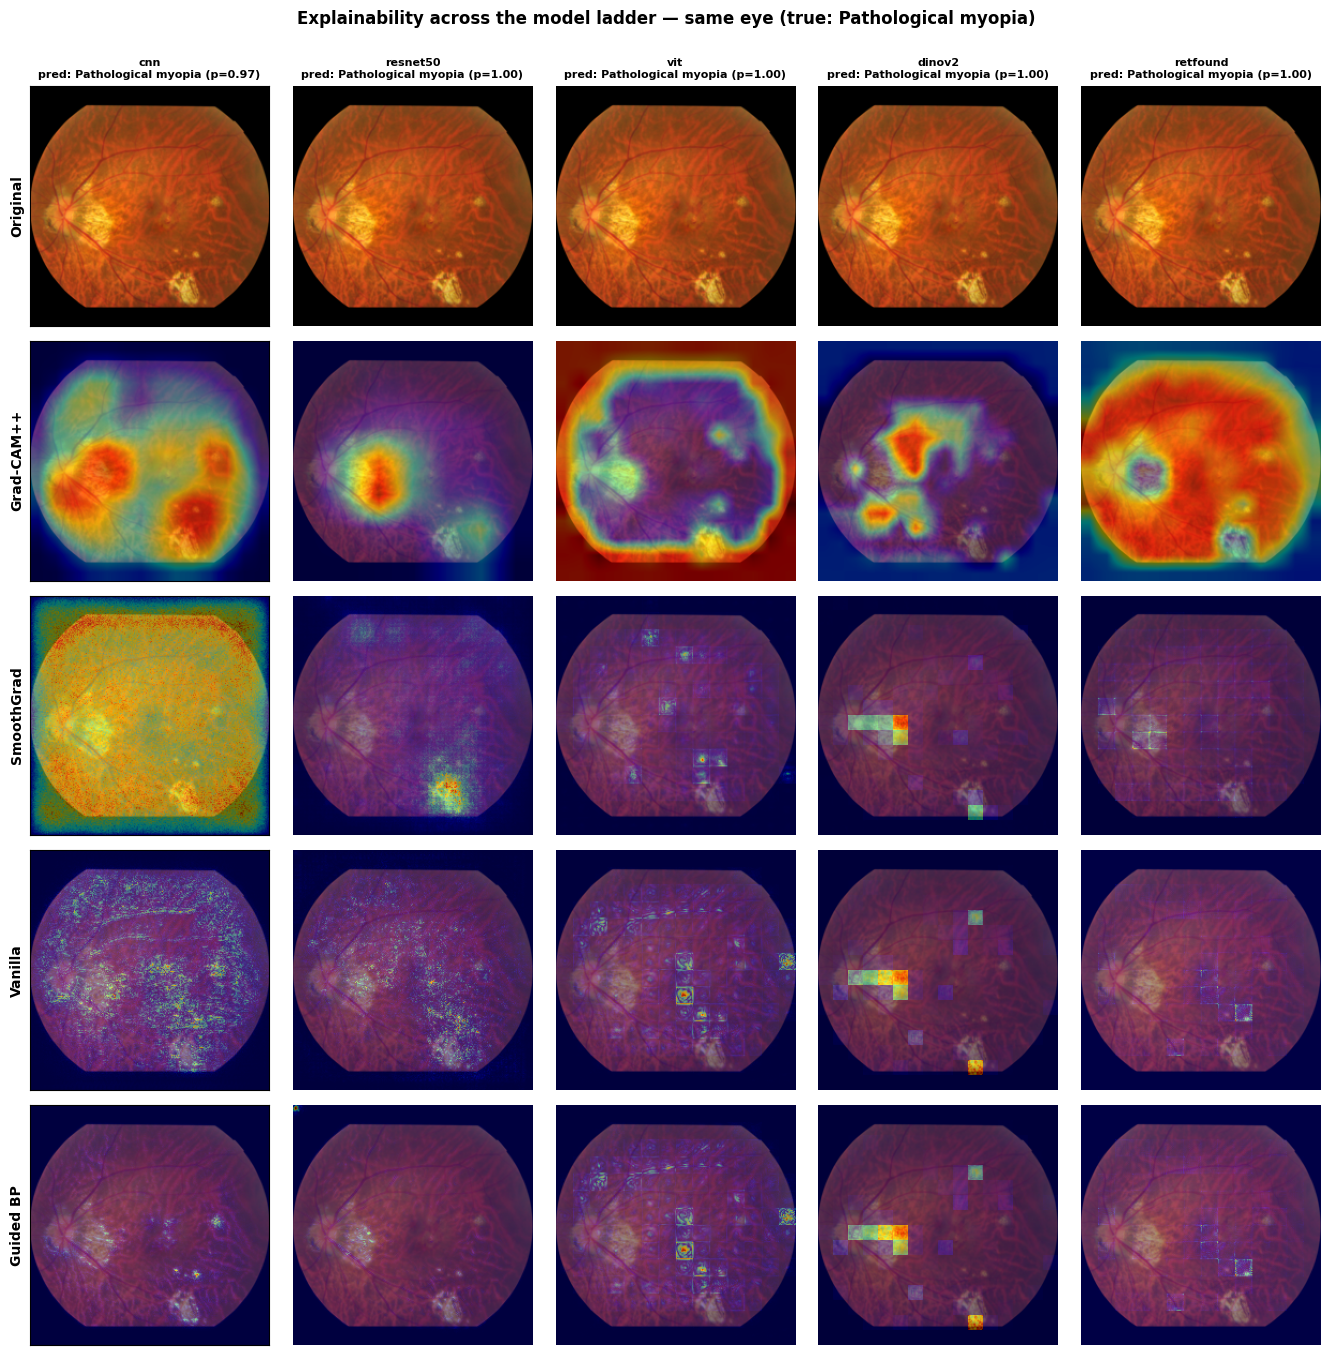

In [ ]:
import os, json, numpy as np, matplotlib.pyplot as plt, torch
import torch.nn.functional as F
from PIL import Image
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ---- config ------------------------------------------------------------
manifest = json.load(open(MANIFEST))   # 06 defines the path, not the loaded list
c2i, i2c   = fl.data.class_index_maps(range(10))
NUM_CLASSES = len(c2i)
short       = fl.metrics.bigclass_short
RETFOUND_CKPT = os.path.join(PROJECT_DIR, "RETFound_cfp_weights.pth")
order      = ["cnn", "resnet50", "vit", "dinov2", "retfound"]
avail      = [m for m in order
             if os.path.exists(os.path.join(RESULTS_DIR, "weights_%s_last_fold.pth" % m))]

# pick one image to explain. default: first glaucoma-ish case present, else index 0.
# override IMG_IDX by hand to inspect a specific eye.
PREFERRED_BIGCLASS = 9   # pathological myopia; change to taste (see short dict)
cand = [i for i, m in enumerate(manifest) if m["bigclass"] == PREFERRED_BIGCLASS]
IMG_IDX = cand[0] if cand else 0
img_row = manifest[IMG_IDX]
img_path = img_row.get("cache_path", img_row["path"])
true_bc  = img_row["bigclass"]
print("explaining image idx %d | true bigclass: %s" % (IMG_IDX, short[c2i[true_bc]]))

# shared 0-1 rgb for overlays (same image for every column)
rgb = np.asarray(Image.open(img_path).convert("RGB").resize((224, 224)), np.float32) / 255.0

def _norm(a):
    a = a - a.min()
    return a / (a.max() + 1e-8)

# ---- attribution methods (all return a 0-1 (224,224) heatmap) -----------
def m_gradcampp(model, name, x, cls):
    tl, reshape = fl.models.gradcam_setup(name, model)
    cam = GradCAMPlusPlus(model=model, target_layers=tl, reshape_transform=reshape)
    return cam(input_tensor=x, targets=[ClassifierOutputTarget(cls)])[0]

def m_vanilla(model, x, cls):
    xi = x.clone().detach().requires_grad_(True)
    model.zero_grad(); out = model(xi); out[0, cls].backward()
    g = xi.grad.detach()[0].abs().amax(0)
    return _norm(F.interpolate(g[None, None], size=224, mode="bilinear",
                               align_corners=False)[0, 0].cpu().numpy())

def m_smoothgrad(model, x, cls, n=25, sigma=0.15):
    xd = x.detach(); rng = (xd.max() - xd.min()).item(); acc = None
    for _ in range(n):
        xn = (xd + torch.randn_like(xd) * sigma * rng).clone().requires_grad_(True)
        model.zero_grad(); out = model(xn); out[0, cls].backward()
        g = xn.grad.detach()[0].abs().amax(0)
        acc = g if acc is None else acc + g
    g = (acc / n)
    return _norm(F.interpolate(g[None, None], size=224, mode="bilinear",
                               align_corners=False)[0, 0].cpu().numpy())

class _GuidedBackprop:
    # version-independent guided backprop: clamp incoming relu gradients to >=0.
    # hooks are registered ONLY during this pass (and inplace relu is disabled),
    # so they never interfere with the grad-cam++/saliency backward passes that
    # run before it -- the previous version left hooks live and crashed the cnn.
    # note: transformers use gelu (no relu), so for vit/dinov2/retfound this
    # degenerates to a vanilla gradient -- it is mainly meaningful for cnn/resnet50.
    def __init__(self, model):
        self.model = model
    @staticmethod
    def _h(mod, gin, gout):
        return (torch.clamp(gin[0], min=0.0),) + tuple(gin[1:])
    def __call__(self, model, x, cls):
        relus = [m for m in model.modules() if isinstance(m, torch.nn.ReLU)]
        saved = [r.inplace for r in relus]
        for r in relus:
            r.inplace = False
        hooks = [r.register_full_backward_hook(self._h) for r in relus]
        try:
            xi = x.clone().detach().requires_grad_(True)
            model.zero_grad(); out = model(xi); out[0, cls].backward()
            g = xi.grad.detach()[0].abs().amax(0).cpu().numpy()
        finally:
            for h in hooks:
                h.remove()
            for r, s in zip(relus, saved):
                r.inplace = s
        return _norm(g)

methods = ["Grad-CAM++", "SmoothGrad", "Vanilla", "Guided BP"]

# ---- build each model, predict, compute all four maps -------------------
def build_trained(name):
    ck = RETFOUND_CKPT if (name == "retfound" and os.path.exists(RETFOUND_CKPT)) else None
    mdl = fl.models.build_model(name, NUM_CLASSES, retfound_ckpt=ck)
    w = os.path.join(RESULTS_DIR, "weights_%s_last_fold.pth" % name)
    mdl.load_state_dict(torch.load(w, map_location=device, weights_only=False))
    return mdl.to(device).eval()

col_data = {}   # name -> dict(pred, prob, maps={method: heatmap})
for name in avail:
    model = build_trained(name)
    _, eval_tf = fl.models.get_transforms(name)      # per-model normalization
    x = eval_tf(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.softmax(model(x), 1)[0]
    pred = int(prob.argmax()); p = float(prob[pred])
    gb = _GuidedBackprop(model)
    maps = {
        "Grad-CAM++": m_gradcampp(model, name, x, pred),
        "SmoothGrad": m_smoothgrad(model, x, pred),
        "Vanilla":    m_vanilla(model, x, pred),
        "Guided BP":  gb(model, x, pred),
    }
    col_data[name] = {"pred": pred, "prob": p, "maps": maps}
    print("  %-9s pred=%-22s p=%.2f" % (name, short[pred], p))
    del model; torch.cuda.empty_cache()

# ---- draw grid: rows = [Original] + methods, cols = models --------------
n_rows, n_cols = 1 + len(methods), len(avail)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.7 * n_cols, 2.7 * n_rows), squeeze=False)
for j, name in enumerate(avail):
    d = col_data[name]
    axes[0, j].imshow(rgb); axes[0, j].axis("off")
    axes[0, j].set_title("%s\npred: %s (p=%.2f)" % (name, short[d["pred"]], d["prob"]),
                         fontsize=8, fontweight="bold")
    for i, meth in enumerate(methods, start=1):
        overlay = show_cam_on_image(rgb, _norm(d["maps"][meth]), use_rgb=True, image_weight=0.55)
        axes[i, j].imshow(overlay); axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(meth, fontsize=10, fontweight="bold")
            axes[i, j].axis("on"); axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
axes[0, 0].axis("on"); axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])
axes[0, 0].set_ylabel("Original", fontsize=10, fontweight="bold")
plt.suptitle("Explainability across the model ladder — same eye (true: %s)" % short[c2i[true_bc]],
             fontsize=12, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "explainability_grid.png"), dpi=150, bbox_inches="tight")
plt.show()


## Precision–Recall curves across the model ladder

Per-disease one-vs-rest PR curves (Fig-2b style), one panel per model, legend showing **AUPRC** (average precision) per class. PR is the more honest view than ROC for the rare bigclasses here — ROC AUC can look strong on a class with 18 positives while precision is actually poor. Saved to `results/pr_grid_models.png`.

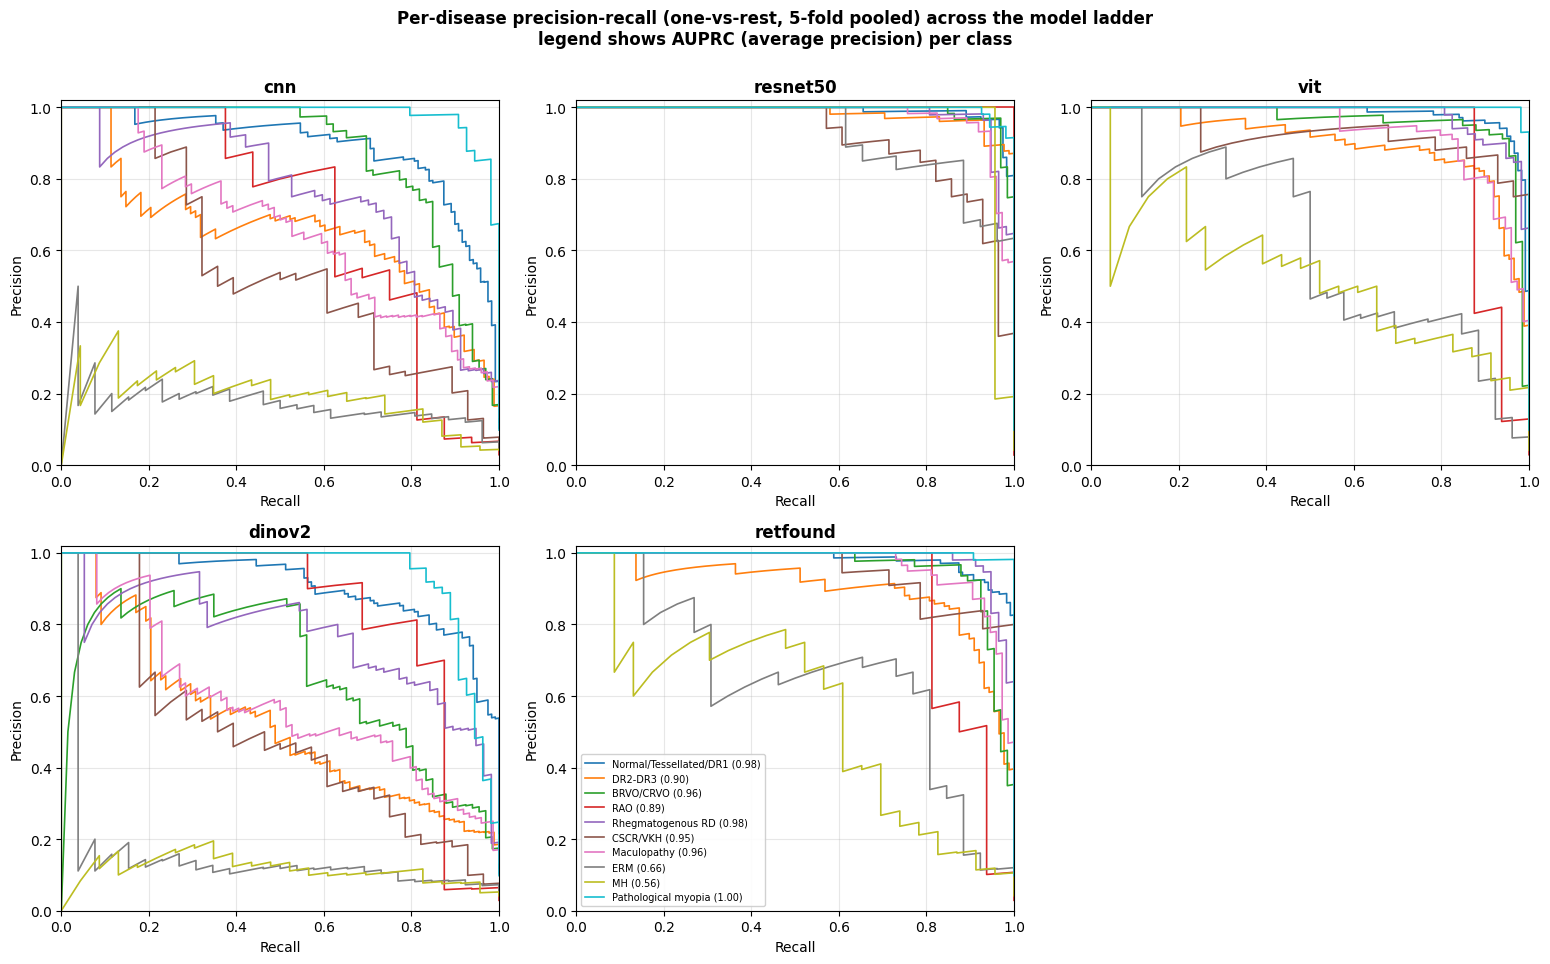

In [ ]:
import os, sys, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# force-reload fundus_lib so the new PR helpers are picked up without a restart
for _m in [m for m in list(sys.modules) if m == "fundus_lib" or m.startswith("fundus_lib.")]:
    del sys.modules[_m]
import fundus_lib as fl

order = ["cnn", "resnet50", "vit", "dinov2", "retfound"]
avail = [m for m in order if os.path.exists(os.path.join(RESULTS_DIR, "preds_%s.npz" % m))]
short = fl.metrics.bigclass_short

cols = 3 if len(avail) >= 3 else max(1, len(avail))
rows = int(np.ceil(len(avail) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5.2 * cols, 4.8 * rows), squeeze=False)
cmap = plt.get_cmap("tab10")

for ax, m in zip(axes.flat, avail):
    d = np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % m))
    yt, yp = d["y_true"], d["y_prob"]
    for k in range(yp.shape[1]):
        b = (yt == k).astype(int)
        if b.sum() == 0 or b.sum() == len(b):
            continue
        precision, recall, _ = precision_recall_curve(b, yp[:, k])
        ap = average_precision_score(b, yp[:, k])
        ax.plot(recall, precision, color=cmap(k % 10), lw=1.2,
                label=f"{short[k]} ({ap:.2f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_title(m, fontweight="bold")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.grid(True, alpha=0.3)
axes.flat[len(avail) - 1].legend(fontsize=7, loc="lower left", framealpha=0.9)
for ax in axes.flat[len(avail):]:
    ax.axis("off")
plt.suptitle("Per-disease precision-recall (one-vs-rest, 5-fold pooled) across the model ladder\n"
             "legend shows AUPRC (average precision) per class",
             fontsize=12, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pr_grid_models.png"), dpi=150, bbox_inches="tight")
plt.show()


## Per-disease AUPRC heatmap

Models × bigclasses, colored by AUPRC. Each column header lists the class **prevalence** — the no-skill AUPRC floor — so a green cell on a rare disease is read against the right baseline (unlike ROC AUC, whose chance line is always 0.5). Saved to `results/auprc_heatmap.png`.

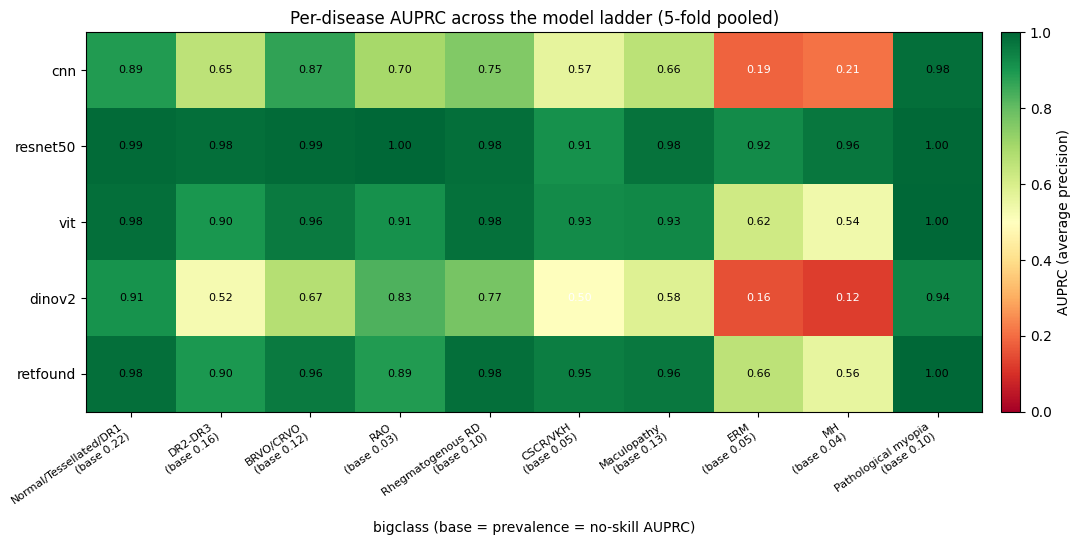

In [ ]:
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

order = ["cnn", "resnet50", "vit", "dinov2", "retfound"]
avail = [m for m in order if os.path.exists(os.path.join(RESULTS_DIR, "preds_%s.npz" % m))]
short = fl.metrics.bigclass_short
K = len(short)

# (M, K) matrix of per-class AUPRC from each model's pooled OOF preds
matrix, labels, prevalence = [], [], None
for m in avail:
    d = np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % m))
    yt, yp = d["y_true"], d["y_prob"]
    if prevalence is None:
        prevalence = [float((yt == k).mean()) for k in range(K)]
    row = []
    for k in range(K):
        b = (yt == k).astype(int)
        row.append(average_precision_score(b, yp[:, k]) if 0 < b.sum() < len(b) else np.nan)
    matrix.append(row); labels.append(m)
M = np.array(matrix)

fig, ax = plt.subplots(figsize=(11, 0.55 * len(labels) + 2.8))
im = ax.imshow(M, cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")
# x labels include the chance baseline (prevalence) so a green cell over a rare
# class is read correctly -- auprc's no-skill floor is the class prevalence.
xlabels = [f"{short[k]}\n(base {prevalence[k]:.2f})" for k in range(K)]
ax.set_xticks(range(K)); ax.set_xticklabels(xlabels, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("bigclass (base = prevalence = no-skill AUPRC)")
ax.set_title("Per-disease AUPRC across the model ladder (5-fold pooled)")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                    fontsize=8, color="black" if M[i, j] > 0.5 else "white")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="AUPRC (average precision)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "auprc_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()


## Precision–recall table

Cross-model macro / frequency-weighted AUPRC summary (`auprc_summary.csv`), then the per-class precision, recall, F1 (at the argmax decision) and AUPRC for the best model by weighted AUPRC (`precision_recall_table_<model>.csv`). `prevalence` is the chance AUPRC for that class.

In [ ]:
import os, numpy as np, pandas as pd
from sklearn.metrics import average_precision_score, precision_recall_fscore_support

# self-contained: computes AUPRC inline with sklearn so it does NOT depend on the
# updated fundus_lib/metrics.py being synced to Drive. only uses bigclass_short.
order = ["cnn", "resnet50", "vit", "dinov2", "retfound"]
avail = [m for m in order if os.path.exists(os.path.join(RESULTS_DIR, "preds_%s.npz" % m))]
short = fl.metrics.bigclass_short

def _auprc_summary(yt, yp):
    aps, w = [], []
    for k in range(yp.shape[1]):
        b = (yt == k).astype(int)
        if 0 < b.sum() < len(b):
            aps.append(average_precision_score(b, yp[:, k])); w.append(b.sum())
    if not aps:
        return float("nan"), float("nan")
    aps = np.array(aps, float); w = np.array(w, float)
    return float(aps.mean()), float(np.average(aps, weights=w))

def _pr_table(yt, yp, names):
    n = yp.shape[1]; yhat = yp.argmax(1)
    prec, rec, f1, sup = precision_recall_fscore_support(
        yt, yhat, labels=list(range(n)), zero_division=0)
    rows = []
    for k in range(n):
        b = (yt == k).astype(int)
        ap = average_precision_score(b, yp[:, k]) if 0 < b.sum() < len(b) else float("nan")
        rows.append({"class": names[k], "support": int(sup[k]), "prevalence": float(b.mean()),
                     "precision": float(prec[k]), "recall": float(rec[k]),
                     "f1": float(f1[k]), "auprc": float(ap)})
    return rows

# cross-model AUPRC summary (macro + frequency-weighted average precision)
summary_rows = []
for m in avail:
    d = np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % m))
    macro, weighted = _auprc_summary(d["y_true"], d["y_prob"])
    summary_rows.append({"model": m, "macro_AUPRC": round(macro, 3),
                         "weighted_AUPRC": round(weighted, 3)})
auprc_df = pd.DataFrame(summary_rows)
auprc_df.to_csv(os.path.join(RESULTS_DIR, "auprc_summary.csv"), index=False)
print("=== cross-model AUPRC summary (5-fold pooled) ===")
print(auprc_df.to_string(index=False))

# per-class precision / recall / f1 / auprc for the best model (by weighted AUPRC)
best = max(avail, key=lambda m: _auprc_summary(
    np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % m))["y_true"],
    np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % m))["y_prob"])[1])
d = np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % best))
pr_df = pd.DataFrame(_pr_table(d["y_true"], d["y_prob"], short))
for c in ["prevalence", "precision", "recall", "f1", "auprc"]:
    pr_df[c] = pr_df[c].round(3)
pr_df.to_csv(os.path.join(RESULTS_DIR, "precision_recall_table_%s.csv" % best), index=False)
print("\n=== per-class precision / recall / AUPRC : %s (best by weighted AUPRC) ===" % best)
print(pr_df.to_string(index=False))
pr_df


=== cross-model AUPRC summary (5-fold pooled) ===
   model  macro_AUPRC  weighted_AUPRC
     cnn        0.647           0.730
resnet50        0.972           0.979
     vit        0.874           0.920
  dinov2        0.600           0.672
retfound        0.884           0.928

=== per-class precision / recall / AUPRC : resnet50 (best by weighted AUPRC) ===
                 class  support  prevalence  precision  recall    f1  auprc
Normal/Tessellated/DR1      119       0.216      0.966   0.958 0.962  0.990
               DR2-DR3       88       0.160      0.953   0.932 0.943  0.983
             BRVO/CRVO       66       0.120      0.955   0.970 0.962  0.990
                   RAO       16       0.029      0.889   1.000 0.941  1.000
     Rhegmatogenous RD       57       0.103      0.963   0.912 0.937  0.982
              CSCR/VKH       28       0.051      0.821   0.821 0.821  0.913
           Maculopathy       74       0.134      0.944   0.919 0.932  0.976
                   ERM       26 

,class,support,prevalence,precision,recall,f1,auprc
0,Normal/Tessellated/DR1,119,0.216,0.966,0.958,0.962,0.990
1,DR2-DR3,88,0.160,0.953,0.932,0.943,0.983
2,BRVO/CRVO,66,0.120,0.955,0.970,0.962,0.990
3,RAO,16,0.029,0.889,1.000,0.941,1.000
4,Rhegmatogenous RD,57,0.103,0.963,0.912,0.937,0.982
5,CSCR/VKH,28,0.051,0.821,0.821,0.821,0.913
6,Maculopathy,74,0.134,0.944,0.919,0.932,0.976
7,ERM,26,0.047,0.767,0.885,0.821,0.922
8,MH,23,0.042,0.917,0.957,0.936,0.965
9,Pathological myopia,54,0.098,0.944,0.944,0.944,0.996
